[  1/10] L= 0.89093 | grad norm= 68268.62328384128
[  2/10] L= 0.47824 | grad norm= 32159.24380556443
[  3/10] L= 0.20706 | grad norm= 13846.392852121637
[  4/10] L= 0.14126 | grad norm= 39732.921411363815
[  5/10] L= 0.12697 | grad norm= 45268.06479185609
[  6/10] L= 0.13899 | grad norm= 39752.348863330655
[  7/10] L= 0.16721 | grad norm= 34112.339434044974
[  8/10] L= 0.23029 | grad norm= 1343.4132689800936
[  9/10] L= 0.32744 | grad norm= 16719.59785086729
[ 10/10] L= 0.40399 | grad norm= 31936.82049203416


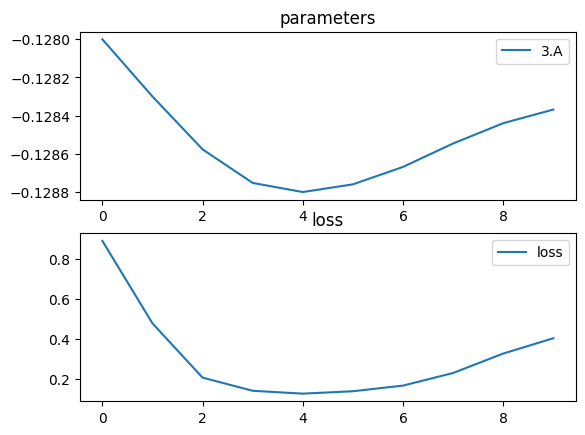

In [11]:
import torch
import torch.nn as nn
import torchlensmaker as tlm
import torch.optim as optim

from torchlensmaker.core.collision_detection import LM

from typing import Any

from torchlensmaker.viewer import tlmviewer

def find_closest_points(surface, P, V):
    N = P.shape[0]
    
    t = torch.zeros(N).unsqueeze(0)
    algo = LM(0.5)

    with torch.no_grad():
        for i in range(30):
            t = t - algo.delta(surface, P, V, t, max_delta=100.0)

    t = t - algo.delta(surface, P, V, t, max_delta=100.0)

    return t.squeeze(0)

def loss(surface, P, V):
    t = find_closest_points(surface, P, V)
    points = P + t.unsqueeze(-1).expand_as(V) * V
    F = surface.F(points)
    return F.sum() / points.shape[0]


class NonImagingRod(nn.Module):
    def __init__(self, surface):
        self.surface = surface
        super().__init__()

    def forward(self, inputs: tlm.OpticalData) -> tlm.OpticalData:
        N, dim = inputs.P.shape
        assert dim == 3

        if N == 0:
            raise RuntimeError("No rays")

        # Convert rays to surface local frame
        P, V = inputs.P, inputs.V
        transform = tlm.forward_kinematic(inputs.transforms)
        P_local = transform.inverse_points(inputs.P)
        V_local = transform.inverse_vectors(inputs.V)
        
        t = find_closest_points(self.surface, P_local, V_local)

        # Closest points
        points_local = P_local + t.unsqueeze(-1).expand_as(V_local) * V_local
        points_global = P + t.unsqueeze(-1).expand_as(V) * V

        loss = self.surface.F(points_local).sum()

        return inputs.replace(loss=inputs.loss + loss)


class RodArtist:
    def render_module(self, collective, module) -> list[Any]:
        tf = collective.input_tree[module].tf()
        s = module.surface
        return [{
            "type": "surface",
            "bcyl": [s.xmin.item(), s.xmax.item(), s.tau.item()],
            "matrix": tf.hom_matrix().tolist()
        }]

    def render_rays(self, collective, module) -> list[Any]:
        inputs = collective.input_tree[module]
        return []

xmin, xmax, tau = torch.tensor([-50/2, 50.2, 37.02/2], dtype=torch.float64).unbind()
cylinder = tlm.ImplicitCylinder(xmin, xmax, tau)

primary = tlm.Parabola(1000, A=tlm.parameter(-0.128), normalize=True)


optics = tlm.Sequential(
    tlm.Gap(-1000),
    tlm.ObjectAtInfinity(beam_diameter = 950., angular_size=1.0),
    tlm.Gap(1000),
    tlm.ReflectiveSurface(primary),
    tlm.Gap(-1000),
    NonImagingRod(cylinder),
)

tlm.show3d(optics, sampling={"base": 100, "object": 10}, extra_artists={NonImagingRod: RodArtist()})

torch.autograd.set_detect_anomaly(True)

tlm.optimize(
    optics,
    optimizer = optim.Adam(optics.parameters(), lr=3e-4),
    sampling = {"base": 100, "object": 5},
    dim = 3,
    num_iter = 10
).plot()



In [12]:
tlm.show3d(optics, sampling={"base": 100, "object": 10}, extra_artists={NonImagingRod: RodArtist()}, end=1100)

print(primary.A.item())

-0.12834694873968255
